In [17]:
from pyspark.sql import SparkSession
import pandas as pd
import numpy as np
import math as m
import pyspark.sql.functions as F
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LassoCV, ElasticNetCV
from sklearn.metrics import root_mean_squared_error, r2_score
import geopandas as gpd
import folium
import matplotlib.pyplot as plt
from utilsforecast.plotting import plot_series
from sklearn.model_selection import train_test_split
from sklearn.multioutput import MultiOutputRegressor
from sklearn.linear_model import SGDRegressor
from xgboost import XGBRegressor
from sklearn.neural_network import MLPRegressor


# Create a spark session (which will run spark jobs)
spark = (
    SparkSession.builder.appName("MAST30034 Tutorial 1")
    .config("spark.sql.repl.eagerEval.enabled", True) 
    .config("spark.sql.parquet.cacheMetadata", "true")
    .config("spark.sql.session.timeZone", "Etc/UTC")
    .config("spark.driver.memory", "6g")
    .getOrCreate()
)

**Outlier Detection Function**

In [18]:
# Outlier detection and treatment using IQR altered from https://www.machinelearningplus.com/pyspark/pyspark-outlier-detection-and-treatment/ to handle large datasets
def iqr_outlier_treatment(dataframe, columns, n):
    """
    Detects and treats outliers using IQR for multiple variables in a PySpark DataFrame.
    :param dataframe: The input PySpark DataFrame
    :param columns: A list of columns to apply IQR outlier treatment
    :param factor: The IQR factor to use for detecting outliers
    :return: The processed DataFrame with outliers treated
    """
    factor = m.sqrt(np.log(n)) - 0.5  
    for column in columns:
        # Calculate Q1, Q3, and IQR
        quantiles = dataframe.approxQuantile(column, [0.25, 0.75], 0.01)
        q1, q3 = quantiles[0], quantiles[1]
        iqr = q3 - q1
        # Define the upper and lower bounds for outliers
        lower_bound = q1 - factor * iqr
        upper_bound = q3 + factor * iqr
        # Filter outliers and update the DataFrame
        dataframe = dataframe.filter((F.col(column) >= lower_bound) & (F.col(column) <= upper_bound))
    return dataframe

**Creating the Training(Analysis) Data**

In [19]:
sdf_2024_green = spark.read.parquet("../taxi_data/green/2024")

sdf_2024_green = sdf_2024_green.withColumnRenamed("lpep_pickup_datetime", "pickup_datetime") \
    .withColumnRenamed("lpep_dropoff_datetime", "dropoff_datetime")\
    .drop("store_and_fwd_flag", "RateCodeID", "passenger_count", "payment_type", "mta_tax", "tolls_amount", "improvement_surcharge", "extra", "trip_type", "ehail_fee")

sdf_2024_yellow = spark.read.parquet("../taxi_data/yellow/2024")

sdf_2024_yellow = sdf_2024_yellow.withColumnRenamed("tpep_pickup_datetime", "pickup_datetime") \
    .withColumnRenamed("tpep_dropoff_datetime", "dropoff_datetime")\
    .drop("Airport_Fee", "store_and_fwd_flag", "RateCodeID", "passenger_count", "payment_type", "mta_tax", "tolls_amount", "improvement_surcharge", "extra", "trip_type", "ehail_fee")

In [20]:
sdf_2023_green = spark.read.parquet("../taxi_data/green/2023")

sdf_2023_green = sdf_2023_green.withColumnRenamed("lpep_pickup_datetime", "pickup_datetime") \
    .withColumnRenamed("lpep_dropoff_datetime", "dropoff_datetime")\
    .drop("store_and_fwd_flag", "RateCodeID", "passenger_count", "payment_type", "mta_tax", "tolls_amount", "improvement_surcharge", "extra", "trip_type", "ehail_fee")

sdf_2023_yellow = spark.read.parquet("../taxi_data/yellow/2023")

sdf_2023_yellow = sdf_2023_yellow.withColumnRenamed("tpep_pickup_datetime", "pickup_datetime") \
    .withColumnRenamed("tpep_dropoff_datetime", "dropoff_datetime")\
    .drop("Airport_Fee", "store_and_fwd_flag", "RateCodeID", "passenger_count", "payment_type", "mta_tax", "tolls_amount", "improvement_surcharge", "extra", "trip_type", "ehail_fee")


In [21]:
sdf_2024 = sdf_2024_green.unionByName(sdf_2024_yellow, allowMissingColumns=True)
sdf_2024.count()

41829938

In [22]:
sdf_2023 = sdf_2023_green.unionByName(sdf_2023_yellow, allowMissingColumns=True)
sdf_2023.count()

15610024

In [23]:
# Read the irregular data for 2023  in the month of October and removed all the rows with null pickup and dropoff datetimes
temp = spark.read.parquet("../taxi_data/irregular")

temp = temp.withColumnRenamed("lpep_pickup_datetime", "pickup_datetime") \
    .withColumnRenamed("lpep_dropoff_datetime", "dropoff_datetime")\
    .drop("store_and_fwd_flag", "RateCodeID", "passenger_count", "payment_type", "mta_tax", "tolls_amount", "improvement_surcharge", "extra", "trip_type", "ehail_fee")

temp_work = temp.filter(F.col("pickup_datetime").isNotNull() & F.col("dropoff_datetime").isNotNull()) \
    .filter(F.col("pickup_datetime") < F.col("dropoff_datetime"))

sdf_2023 = sdf_2023.unionByName(temp_work, allowMissingColumns=True)

sdf_2023.count()

15676112

In [24]:
sdf_train = sdf_2023.unionByName(sdf_2024, allowMissingColumns=True)
sdf_train.count()

57506050

In [25]:
sdf_train.show(10)

+--------+-------------------+-------------------+------------+------------+-------------+-----------+----------+------------+--------------------+
|VendorID|    pickup_datetime|   dropoff_datetime|PULocationID|DOLocationID|trip_distance|fare_amount|tip_amount|total_amount|congestion_surcharge|
+--------+-------------------+-------------------+------------+------------+-------------+-----------+----------+------------+--------------------+
|       1|2023-09-01 00:08:04|2023-09-01 00:13:39|          41|          75|          1.1|        7.9|       0.0|        10.4|                 0.0|
|       1|2023-09-01 00:30:44|2023-09-01 00:39:30|          74|         236|          1.8|       10.7|      3.15|        19.1|                2.75|
|       2|2023-09-01 00:14:39|2023-09-01 00:38:30|          93|         205|        10.52|       60.0|       0.0|        61.0|                 0.0|
|       2|2023-09-01 00:35:48|2023-09-01 00:56:48|         112|          17|         4.72|       23.3|      10.0

**Creating Test Data**

In [26]:
sdf_2025_green = spark.read.parquet("../taxi_data/green/2025")

sdf_2025_green = sdf_2025_green.withColumnRenamed("lpep_pickup_datetime", "pickup_datetime") \
    .withColumnRenamed("lpep_dropoff_datetime", "dropoff_datetime")\
    .drop("store_and_fwd_flag", "RateCodeID", "passenger_count", "payment_type", "mta_tax", "tolls_amount", "improvement_surcharge", "extra", "trip_type", "ehail_fee", "cbd_congestion_fee")

sdf_2025_yellow = spark.read.parquet("../taxi_data/yellow/2025")

sdf_2025_yellow = sdf_2025_yellow.withColumnRenamed("tpep_pickup_datetime", "pickup_datetime") \
    .withColumnRenamed("tpep_dropoff_datetime", "dropoff_datetime")\
    .drop("Airport_Fee", "store_and_fwd_flag", "RateCodeID", "passenger_count", "payment_type", "mta_tax", "tolls_amount", "improvement_surcharge", "extra", "trip_type", "ehail_fee", "cbd_congestion_fee")

In [27]:
sdf_2025 = sdf_2025_green.unionByName(sdf_2025_yellow, allowMissingColumns=True)
sdf_2025.count()

24386791

**Creating Weather Data for both Datasets**

In [28]:
weather_train = spark.read.csv("../taxi_data/2023and2024 Weather.csv", header=True, inferSchema=True)
weather_train = weather_train.select("datetime", "temp", "icon")
weather_train

datetime,temp,icon
2023-01-01,11.1,rain
2023-01-02,11.1,rain
2023-01-03,10.7,rain
2023-01-04,14.3,rain
2023-01-05,8.8,rain
2023-01-06,7.0,rain
2023-01-07,4.8,partly-cloudy-day
2023-01-08,3.1,partly-cloudy-day
2023-01-09,4.5,rain
2023-01-10,4.3,partly-cloudy-day


In [29]:
weather_test = spark.read.csv("../taxi_data/2025 Weather.csv", header=True, inferSchema=True)
weather_test = weather_test.select("datetime", "temp", "icon")

**Preprocessing for Train Data**

In [30]:
# Calculate travel time in seconds
sdf_train = sdf_train.withColumn("travel_time_seconds",\
    (F.unix_timestamp("dropoff_datetime") - F.unix_timestamp("pickup_datetime")))
# filtering the data for valid trips
# travel time should be greater than  or equal to 3 minutes (180 seconds) and less than or equal to 5 hours (18000 seconds) 
# trip distance should be greater than 1 mile as it is reasonable to assume that a taxi ride should cover some distance more than a mile to be stuck in traffic and be worth it
# fare amount should be greater than 3 dollars and total amount should be greater than 3 dollars as according to the NYC Taxi and Limousine Commission,\
#  the initial fare for a taxi ride is $3.00
sdf_train_filtered = sdf_train.filter((F.col("travel_time_seconds") >= 180) & (F.col("trip_distance") > 1) & (F.col("fare_amount") > 3) & (F.col("total_amount") > 3) \
    & (F.col("travel_time_seconds") <= 18000))

# congestion surcharge should be greater than or equal to 0 and not null as according to https://www.nyc.gov/site/tlc/about/congestion-surcharge.page
sdf_train_filtered = sdf_train_filtered.withColumn("congestion_surcharge",\
    F.when((F.col("congestion_surcharge").isNotNull()) & ~(F.isnan("congestion_surcharge")), F.col("congestion_surcharge")).otherwise(0))

# Checking NaN or null values in the dataframe
# adapted from https://sparkbyexamples.com/pyspark/pyspark-find-count-of-null-none-nan-values/
sdf_train_filtered.select([F.count(F.when(F.isnan(c) | F.col(c).isNull(), c)).alias(c) for c in sdf_train_filtered.drop("pickup_datetime", "dropoff_datetime").columns])

# removing outlier trips based on travel time and trip distance
sdf_train_filtered_outlier = iqr_outlier_treatment(sdf_train_filtered, ["travel_time_seconds", "trip_distance"], n = sdf_train_filtered.count())

# adding a date column for each trip and removing the unnecessary columns
split_col1 = F.split(sdf_train_filtered_outlier['pickup_datetime'], ' ')
sdf_train_filtered_outlier = sdf_train_filtered_outlier.withColumn('date', split_col1.getItem(0)).orderBy("date", ascending=True)
sdf_train_filtered_outlier = sdf_train_filtered_outlier.filter((F.col("date") >= "2023-07-01") & (F.col("date") <= "2024-12-31"))
sdf_train_filtered_outlier = sdf_train_filtered_outlier.drop("pickup_datetime", "dropoff_datetime", "PULocationID", "VendorID", "congestion_surcharge")

sdf_train_filtered_outlier.show(10)

+------------+-------------+-----------+----------+------------+-------------------+----------+
|DOLocationID|trip_distance|fare_amount|tip_amount|total_amount|travel_time_seconds|      date|
+------------+-------------+-----------+----------+------------+-------------------+----------+
|         170|         3.45|       17.0|      4.45|        26.7|                798|2023-07-01|
|         263|          1.8|       12.1|       5.1|        22.2|                616|2023-07-01|
|         262|         1.49|       10.0|      3.05|        18.3|                434|2023-07-01|
|         163|         2.31|       19.1|       0.0|        24.1|               1219|2023-07-01|
|          75|         9.32|       38.0|       0.0|       43.25|               1268|2023-07-01|
|         262|         2.36|       13.5|       3.7|        22.2|                624|2023-07-01|
|         238|          1.3|        9.3|      1.77|       13.57|                393|2023-07-01|
|          24|         4.36|       19.8|

In [31]:
sdf_train_filtered_outlier.count()

39642532

In [32]:
# average new york taxi speed according to https://medium.com/@jiaminhan/looking-through-the-taxi-meter-analysis-of-the-nyc-green-taxi-data-c1dbe5619afe
average_speed = 14 / 3600 # in miles per second

# tolerance time for congestion time
tolerance = 120

sdf_train_filtered_outlier = sdf_train_filtered_outlier.withColumn("congestion_time_seconds",\
    F.when((F.col("travel_time_seconds") - (F.col("trip_distance") / average_speed) >= tolerance),\
    (F.col("travel_time_seconds") - (F.col("trip_distance") / average_speed))).otherwise(0))

In [33]:
sdf_train_filtered_outlier.orderBy("congestion_time_seconds", ascending=False).show(10)

+------------+-------------+-----------+----------+------------+-------------------+----------+-----------------------+
|DOLocationID|trip_distance|fare_amount|tip_amount|total_amount|travel_time_seconds|      date|congestion_time_seconds|
+------------+-------------+-----------+----------+------------+-------------------+----------+-----------------------+
|         230|         1.06|        6.5|       0.0|        11.5|               4429|2024-08-22|      4156.428571428572|
|         158|         1.05|       63.9|     15.47|       92.81|               4426|2023-09-08|                 4156.0|
|          61|          1.1|       28.5|       0.0|        29.0|               4430|2024-10-21|      4147.142857142857|
|         132|         1.08|       70.0|     25.03|      108.47|               4417|2024-06-10|      4139.285714285715|
|         234|         1.14|       10.0|       0.0|        15.0|               4432|2024-11-22|      4138.857142857143|
|          29|          1.1|       16.5|

In [61]:
# filtering out rows where congestion time is less than 0 to find trips that were in congestion
final_filtered_df = sdf_train_filtered_outlier.filter(F.col("congestion_time_seconds") > 0)
final_filtered_df.count()

26028146

**Adding Weather Data**

In [ ]:
final_filtered_df = final_filtered_df.join(weather_train, final_filtered_df["date"] == weather_train["datetime"], how="inner")\
    .select(
    final_filtered_df["*"],     
    weather_train["temp"],  # only bring the weather columns you care about
    weather_train["icon"]
)
final_filtered_df.show(10)

+------------+-------------+-----------+----------+------------+-------------------+----------+-----------------------+----+-----------------+
|DOLocationID|trip_distance|fare_amount|tip_amount|total_amount|travel_time_seconds|      date|congestion_time_seconds|temp|             icon|
+------------+-------------+-----------+----------+------------+-------------------+----------+-----------------------+----+-----------------+
|         129|         1.32|       10.0|       0.0|        12.5|                511|2023-08-31|     171.57142857142856|21.2|partly-cloudy-day|
|         151|         2.46|       15.6|      3.62|       21.72|                853|2023-09-01|     220.42857142857144|20.0|        clear-day|
|         181|         3.12|       18.4|      4.18|       25.08|               1022|2023-08-31|     219.71428571428567|21.2|partly-cloudy-day|
|          89|         7.99|       45.7|       0.0|        48.2|               2823|2023-09-01|      768.4285714285711|20.0|        clear-day|

DOLocationID,trip_distance,fare_amount,tip_amount,total_amount,travel_time_seconds,date,congestion_time_seconds,temp,icon
0,0,0,0,0,0,0,0,0,0


**Preprocessing for Test Data**

In [36]:
# Calculate travel time in seconds
sdf_2025 = sdf_2025.withColumn("travel_time_seconds",\
    (F.unix_timestamp("dropoff_datetime") - F.unix_timestamp("pickup_datetime")))
# filtering the data for valid trips
# travel time should be greater than  or equal to 3 minutes (180 seconds) and less than or equal to 5 hours (18000 seconds) 
# trip distance should be greater than 1 mile as it is reasonable to assume that a taxi ride should cover some distance more than a mile to be stuck in traffic and be worth it
# fare amount should be greater than 3 dollars and total amount should be greater than 3 dollars as according to the NYC Taxi and Limousine Commission,\
#  the initial fare for a taxi ride is $3.00
sdf_2025_filtered = sdf_2025.filter((F.col("travel_time_seconds") >= 180) & (F.col("trip_distance") > 1) & (F.col("fare_amount") > 3) & (F.col("total_amount") > 3) \
    & (F.col("travel_time_seconds") <= 18000))

# congestion surcharge should be greater than or equal to 0 and not null as according to https://www.nyc.gov/site/tlc/about/congestion-surcharge.page
sdf_2025_filtered = sdf_2025_filtered.withColumn("congestion_surcharge",\
    F.when((F.col("congestion_surcharge").isNotNull()) & ~(F.isnan("congestion_surcharge")), F.col("congestion_surcharge")).otherwise(0))

# Checking NaN or null values in the dataframe
# adapted from https://sparkbyexamples.com/pyspark/pyspark-find-count-of-null-none-nan-values/
sdf_2025_filtered.select([F.count(F.when(F.isnan(c) | F.col(c).isNull(), c)).alias(c) for c in sdf_2025_filtered.drop("pickup_datetime", "dropoff_datetime").columns])

# removing outlier trips based on travel time and trip distance
sdf_2025_filtered_outlier = iqr_outlier_treatment(sdf_2025_filtered, ["travel_time_seconds", "trip_distance"], n = sdf_2025_filtered.count())

# adding a date column for each trip and removing the unnecessary columns
split_col2 = F.split(sdf_2025_filtered_outlier['pickup_datetime'], ' ')
sdf_2025_filtered_outlier = sdf_2025_filtered_outlier.withColumn('date', split_col2.getItem(0)).orderBy("date", ascending=True)
sdf_2025_filtered_outlier = sdf_2025_filtered_outlier.filter((F.col("date") >= "2025-01-01") & (F.col("date") <= "2025-06-30"))
sdf_2025_filtered_outlier = sdf_2025_filtered_outlier.drop("pickup_datetime", "dropoff_datetime", "PULocationID", "VendorID", "congestion_surcharge")

sdf_2025_filtered_outlier.show(10)

+------------+-------------+-----------+----------+------------+-------------------+----------+
|DOLocationID|trip_distance|fare_amount|tip_amount|total_amount|travel_time_seconds|      date|
+------------+-------------+-----------+----------+------------+-------------------+----------+
|         235|         5.93|       24.7|       6.8|        34.0|                851|2025-01-01|
|          48|         3.88|       6.02|       0.0|       10.02|               2214|2025-01-01|
|         237|          1.6|       10.0|       3.0|        18.0|                501|2025-01-01|
|          50|         3.07|      13.95|       0.0|       17.95|               1988|2025-01-01|
|          75|         1.32|        8.6|       0.0|        11.1|                353|2025-01-01|
|         233|         1.55|       5.06|       0.0|        9.06|                607|2025-01-01|
|          68|         2.63|       19.1|       0.0|        24.1|               1202|2025-01-01|
|         162|          2.6|      18.42|

In [37]:
sdf_2025_filtered.select([F.count(F.when(F.isnan(c) | F.col(c).isNull(), c)).alias(c) for c in sdf_2025_filtered.drop("pickup_datetime", "dropoff_datetime").columns])

VendorID,PULocationID,DOLocationID,trip_distance,fare_amount,tip_amount,total_amount,congestion_surcharge,travel_time_seconds
0,0,0,0,0,0,0,0,0


In [38]:
sdf_2025_filtered_outlier = sdf_2025_filtered_outlier.withColumn("congestion_time_seconds",\
    F.when((F.col("travel_time_seconds") - (F.col("trip_distance") / average_speed) >= tolerance),\
    (F.col("travel_time_seconds") - (F.col("trip_distance") / average_speed))).otherwise(0))

sdf_2025_filtered_outlier.show(10)

+------------+-------------+-----------+----------+------------+-------------------+----------+-----------------------+
|DOLocationID|trip_distance|fare_amount|tip_amount|total_amount|travel_time_seconds|      date|congestion_time_seconds|
+------------+-------------+-----------+----------+------------+-------------------+----------+-----------------------+
|         235|         5.93|       24.7|       6.8|        34.0|                851|2025-01-01|                    0.0|
|          48|         3.88|       6.02|       0.0|       10.02|               2214|2025-01-01|     1216.2857142857142|
|         237|          1.6|       10.0|       3.0|        18.0|                501|2025-01-01|                    0.0|
|          50|         3.07|      13.95|       0.0|       17.95|               1988|2025-01-01|     1198.5714285714284|
|          75|         1.32|        8.6|       0.0|        11.1|                353|2025-01-01|                    0.0|
|         233|         1.55|       5.06|

In [66]:
final_filtered_testdf = sdf_2025_filtered_outlier.filter(F.col("congestion_time_seconds") > 0)
final_filtered_testdf.count()

10323231

**Adding Weather Data**

In [67]:
final_filtered_testdf = final_filtered_testdf.join(weather_test, final_filtered_testdf["date"] == weather_test["datetime"], how="inner")\
    .select(
    final_filtered_testdf["*"],     
    weather_test["temp"],  # only bring the weather columns you care about
    weather_test["icon"]
)
final_filtered_testdf.show(10)

+------------+-------------+-----------+----------+------------+-------------------+----------+-----------------------+----+-----------------+
|DOLocationID|trip_distance|fare_amount|tip_amount|total_amount|travel_time_seconds|      date|congestion_time_seconds|temp|             icon|
+------------+-------------+-----------+----------+------------+-------------------+----------+-----------------------+----+-----------------+
|         179|          3.0|       18.4|       0.0|        20.9|               1060|2025-05-01|     288.57142857142856|16.0|partly-cloudy-day|
|          70|         2.15|       13.5|       0.0|        16.0|                751|2025-05-01|      198.1428571428571|16.0|partly-cloudy-day|
|         262|         1.52|       10.7|      2.39|       18.34|                538|2025-05-01|      147.1428571428571|16.0|partly-cloudy-day|
|         166|         1.44|       12.1|      2.92|       17.52|                644|2025-05-01|      273.7142857142857|16.0|partly-cloudy-day|

**Data Analysis**

In [ ]:
# Calculate median congestion time and total trips for each DOLocationID
# median used because of obvious skewness in the data (see histogram below)
congestion_groupby = final_filtered_df.groupBy("DOLocationID").agg(F.expr("percentile_approx(congestion_time_seconds, 0.5)").alias("median_congestion_time_seconds"),\
    F.count("DOLocationID").alias("total_trips"))

congestion_groupby.orderBy("median_congestion_time_seconds", ascending=False).show(10)


[172.766s][warning][gc,alloc] Executor task launch worker for task 2.0 in stage 60.0 (TID 767): Retried waiting for GCLocker too often allocating 16777218 words


25/08/30 17:35:25 WARN TaskMemoryManager: Failed to allocate a page (134217728 bytes), try again.


+------------+------------------------------+-----------+
|DOLocationID|median_congestion_time_seconds|total_trips|
+------------+------------------------------+-----------+
|         204|            2151.5714285714284|          1|
|         105|             952.8571428571428|          9|
|         156|             866.5714285714284|          3|
|          46|             837.1428571428573|         57|
|         214|             749.5714285714284|         15|
|           5|             743.5714285714284|          4|
|         222|             724.2857142857142|       2618|
|          55|             673.2857142857142|       2594|
|          26|             644.1428571428571|       4075|
|          27|             643.8571428571429|         34|
+------------+------------------------------+-----------+
only showing top 10 rows



In [ ]:
# add a column to the dataframe
sum_total_trips = congestion_groupby.select(F.sum("total_trips").alias("sum_total_trips")).collect()[0]["sum_total_trips"]

congestion_groupby = congestion_groupby.withColumn("proportion_of_congestion_time",\
    F.col("median_congestion_time_seconds") * (F.col("total_trips") / sum_total_trips))

congestion_groupby = congestion_groupby.withColumnRenamed("DOLocationID", "LocationID")
congestion_groupby.orderBy("proportion_of_congestion_time", ascending=False).show(10)

# This shows LocationID 161 (Manhattan,Midtown Center) has the highest proportion of congestion time in NYC taxi rides in 2023 and 2024

+----------+------------------------------+-----------+-----------------------------+
|LocationID|median_congestion_time_seconds|total_trips|proportion_of_congestion_time|
+----------+------------------------------+-----------+-----------------------------+
|       161|             483.1428571428571|    1088635|           20.207594666393614|
|       230|             537.7142857142857|     849829|            17.55657870192851|
|       237|             366.2857142857142|    1074459|              15.120515394593|
|       236|             328.1428571428571|    1094226|           13.795160285331116|
|       170|             410.8571428571429|     805392|           12.713201163079384|
|       163|             445.7142857142857|     741929|           12.705029174406594|
|       162|             420.1428571428571|     782172|           12.625715979046022|
|        48|             451.2857142857143|     679090|           11.774315992936483|
|       186|             457.8571428571429|     667946

**GeoVisualization**

In [ ]:
# Load the shapefile (use the .shp file as entry point)
sf = gpd.read_file("../taxi_data/taxi_zones/taxi_zones.shp")
sf.head()

# Convert the geometry shape to to latitude and longitude
# Please attribute this if you are using it
sf['geometry'] = sf['geometry'].to_crs("+proj=longlat +ellps=WGS84 +datum=WGS84 +no_defs")
sf.head()

,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry
0,1,0.116357,0.000782,Newark Airport,1,EWR,"POLYGON ((-74.18445 40.695, -74.18449 40.6951,..."
1,2,0.433470,0.004866,Jamaica Bay,2,Queens,"MULTIPOLYGON (((-73.82338 40.63899, -73.82277 ..."
2,3,0.084341,0.000314,Allerton/Pelham Gardens,3,Bronx,"POLYGON ((-73.84793 40.87134, -73.84725 40.870..."
3,4,0.043567,0.000112,Alphabet City,4,Manhattan,"POLYGON ((-73.97177 40.72582, -73.97179 40.725..."
4,5,0.092146,0.000498,Arden Heights,5,Staten Island,"POLYGON ((-74.17422 40.56257, -74.17349 40.562..."


In [ ]:
zones = pd.read_csv("../taxi_data/taxi_zones/taxi_zone_lookup.csv")
zones.head()

,LocationID,Borough,Zone,service_zone
0,1,EWR,Newark Airport,EWR
1,2,Queens,Jamaica Bay,Boro Zone
2,3,Bronx,Allerton/Pelham Gardens,Boro Zone
3,4,Manhattan,Alphabet City,Yellow Zone
4,5,Staten Island,Arden Heights,Boro Zone


In [ ]:
zones_df = gpd.GeoDataFrame(
    pd.merge(zones, sf, on='LocationID', how='inner')
)
zones_df.head()


,LocationID,Borough,Zone,service_zone,OBJECTID,Shape_Leng,Shape_Area,zone,borough,geometry
0,1,EWR,Newark Airport,EWR,1,0.116357,0.000782,Newark Airport,EWR,"POLYGON ((-74.18445 40.695, -74.18449 40.6951,..."
1,2,Queens,Jamaica Bay,Boro Zone,2,0.433470,0.004866,Jamaica Bay,Queens,"MULTIPOLYGON (((-73.82338 40.63899, -73.82277 ..."
2,3,Bronx,Allerton/Pelham Gardens,Boro Zone,3,0.084341,0.000314,Allerton/Pelham Gardens,Bronx,"POLYGON ((-73.84793 40.87134, -73.84725 40.870..."
3,4,Manhattan,Alphabet City,Yellow Zone,4,0.043567,0.000112,Alphabet City,Manhattan,"POLYGON ((-73.97177 40.72582, -73.97179 40.725..."
4,5,Staten Island,Arden Heights,Boro Zone,5,0.092146,0.000498,Arden Heights,Staten Island,"POLYGON ((-74.17422 40.56257, -74.17349 40.562..."


In [ ]:
congestion_groupby_pd = congestion_groupby.toPandas()
congestion_geodata = congestion_groupby_pd.merge(zones_df[['LocationID', 'geometry']], on='LocationID', how='inner')
congestion_geodata.head()

,LocationID,median_congestion_time_seconds,total_trips,proportion_of_congestion_time,geometry
0,148,404.142857,340937,5.293779,"POLYGON ((-73.98448 40.72023, -73.98507 40.719..."
1,243,407.142857,14256,0.222998,"POLYGON ((-73.93157 40.86958, -73.93141 40.868..."
2,31,468.571429,286,0.005149,"POLYGON ((-73.87094 40.85727, -73.87094 40.857..."
3,85,556.428571,4816,0.102956,"POLYGON ((-73.94716 40.65559, -73.94703 40.654..."
4,137,357.000000,332033,4.554138,"POLYGON ((-73.9722 40.7404, -73.97222 40.74031..."


In [ ]:
# create a JSON 
geoJSON = zones_df[['LocationID', 'geometry']].drop_duplicates('LocationID').to_json()

In [ ]:
map_1 = folium.Map(
    location=[40.66, -73.94],
    tiles="https://stamen-tiles.a.ssl.fastly.net/terrain/{z}/{x}/{y}{r}.png",
    attr='Map tiles by <a href="https://stamen.com/">Stamen Design</a>, '
         '<a href="https://www.openstreetmap.org/copyright">OpenStreetMap</a> contributors',
    zoom_start=10
)

# refer to the folium documentations on how to plot aggregated data.
map_1.add_child(folium.Choropleth(
    geo_data=geoJSON, # geoJSON 
    name='choropleth', # name of plot
    data=congestion_geodata.reset_index(), # data source
    columns=['LocationID','median_congestion_time_seconds'], # the columns required
    key_on='properties.LocationID', # this is from the geoJSON's properties
    fill_color='YlOrRd', # color scheme
    nan_fill_color='black',
    legend_name='Median Congestion Time (seconds)'
))

map_1.save('../plots/foliumChoroplethMap1.html')

map_2 = folium.Map(
    location=[40.66, -73.94],
    tiles="https://stamen-tiles.a.ssl.fastly.net/terrain/{z}/{x}/{y}{r}.png",
    attr='Map tiles by <a href="https://stamen.com/">Stamen Design</a>, '
         '<a href="https://www.openstreetmap.org/copyright">OpenStreetMap</a> contributors',
    zoom_start=10
)

# refer to the folium documentations on how to plot aggregated data.
map_2.add_child(folium.Choropleth(
    geo_data=geoJSON, # geoJSON 
    name='choropleth', # name of plot
    data=congestion_geodata.reset_index(), # data source
    columns=['LocationID','proportion_of_congestion_time'], # the columns required
    key_on='properties.LocationID', # this is from the geoJSON's properties
    fill_color='YlOrRd', # color scheme
    nan_fill_color='black',
    legend_name='Proportion of Congestion Time'\
))

map_2.save('../plots/foliumChoroplethMap2.html')

**Congestion Time VS Travel Time Distribution**

In [ ]:
# so that visualization uses a much smaller dataset size
final_filtered_df_pd = final_filtered_df.sample(fraction=0.2, seed=23).toPandas()

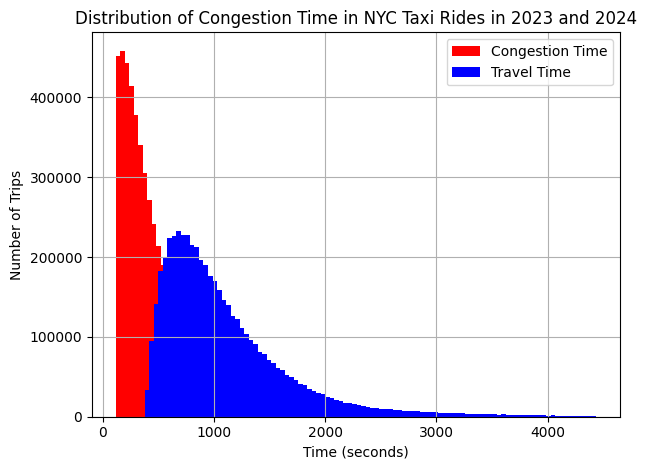

In [ ]:
fig, ax = plt.subplots()
final_filtered_df_pd['congestion_time_seconds'].hist(ax=ax, bins = 100, color='red')
final_filtered_df_pd['travel_time_seconds'].hist(ax=ax, bins = 100, color='blue')
xlabel = "Time (seconds)"
ax.set_xlabel(xlabel)
ylabel = "Number of Trips"
ax.set_ylabel(ylabel)
title = "Distribution of Congestion Time in NYC Taxi Rides in 2023 and 2024"
ax.set_title(title)
ax.legend(['Congestion Time', 'Travel Time'])
plt.tight_layout()  
plt.show()

**Time Series Analysis**

In [68]:
dategroup_traindf = final_filtered_df.groupBy("DOLocationID", "date").agg(F.count("*").alias("trip_count"), F.expr("percentile_approx(congestion_time_seconds, 0.5)").alias("median_congestion_time_seconds"),\
    F.sum("congestion_time_seconds").alias("daily_congestion"), F.avg("travel_time_seconds").alias("average_travel_time_seconds"), F.sum("trip_distance").alias("total_trip_distance"),\
    F.avg("trip_distance").alias("average_trip_distance"),F.sum("fare_amount").alias("total_fare_amount"), F.sum("tip_amount").alias("total_tip_amount"),\
    F.sum("total_amount").alias("total_amount"), F.avg("total_amount").alias("avg_total_amount"), F.max("temp").alias("temperature"), F.first("icon").alias("condition")).orderBy("DOLocationID", "date")

dategroup_traindf.count()

112830

In [69]:
dategroup_testdf = final_filtered_testdf.groupBy("DOLocationID", "date").agg(F.count("*").alias("trip_count"), F.expr("percentile_approx(congestion_time_seconds, 0.5)").alias("median_congestion_time_seconds"),\
    F.sum("congestion_time_seconds").alias("daily_congestion"), F.avg("travel_time_seconds").alias("average_travel_time_seconds"), F.sum("trip_distance").alias("total_trip_distance"),\
    F.avg("trip_distance").alias("average_trip_distance"),F.sum("fare_amount").alias("total_fare_amount"), F.sum("tip_amount").alias("total_tip_amount"),\
    F.sum("total_amount").alias("total_amount"), F.avg("total_amount").alias("avg_total_amount"), F.max("temp").alias("temperature"), F.first("icon").alias("condition")).orderBy("DOLocationID", "date")

dategroup_testdf.count()

39835

In [70]:
dategroup_testdf.show(10)

25/08/31 12:33:13 WARN TaskMemoryManager: Failed to allocate a page (16777200 bytes), try again.
25/08/31 12:33:16 WARN TaskMemoryManager: Failed to allocate a page (16777200 bytes), try again.
25/08/31 12:33:16 WARN TaskMemoryManager: Failed to allocate a page (16777200 bytes), try again.
25/08/31 12:33:17 WARN TaskMemoryManager: Failed to allocate a page (16777200 bytes), try again.
25/08/31 12:33:18 WARN TaskMemoryManager: Failed to allocate a page (16777200 bytes), try again.
25/08/31 12:33:18 WARN TaskMemoryManager: Failed to allocate a page (16777200 bytes), try again.
25/08/31 12:33:19 WARN TaskMemoryManager: Failed to allocate a page (16777200 bytes), try again.
25/08/31 12:33:20 WARN TaskMemoryManager: Failed to allocate a page (16777200 bytes), try again.
25/08/31 12:33:21 WARN TaskMemoryManager: Failed to allocate a page (16777200 bytes), try again.
25/08/31 12:33:21 WARN TaskMemoryManager: Failed to allocate a page (16777200 bytes), try again.
25/08/31 12:33:24 WARN TaskMem

KeyboardInterrupt: 

25/08/31 12:33:41 WARN TaskMemoryManager: Failed to allocate a page (16777200 bytes), try again.
25/08/31 12:33:41 WARN TaskMemoryManager: Failed to allocate a page (16777200 bytes), try again.
25/08/31 12:33:41 WARN TaskMemoryManager: Failed to allocate a page (16777200 bytes), try again.


In [ ]:
# convert to pandas df for visualizations
dategroup_traindf_pd = dategroup_traindf.toPandas()
dategroup_testdf_pd = dategroup_testdf.toPandas()

dategroup_traindf_pd.shape, dategroup_testdf_pd.shape

((112830, 12), (39835, 12))

In [ ]:
# this list contrains the LocationIDs with the highest proportion of congestion time in NYC taxi rides in 2023 and 2024 and 2 random ones
unique_ids = [161, 230, 237, 236, 170, 163, 123, 17]

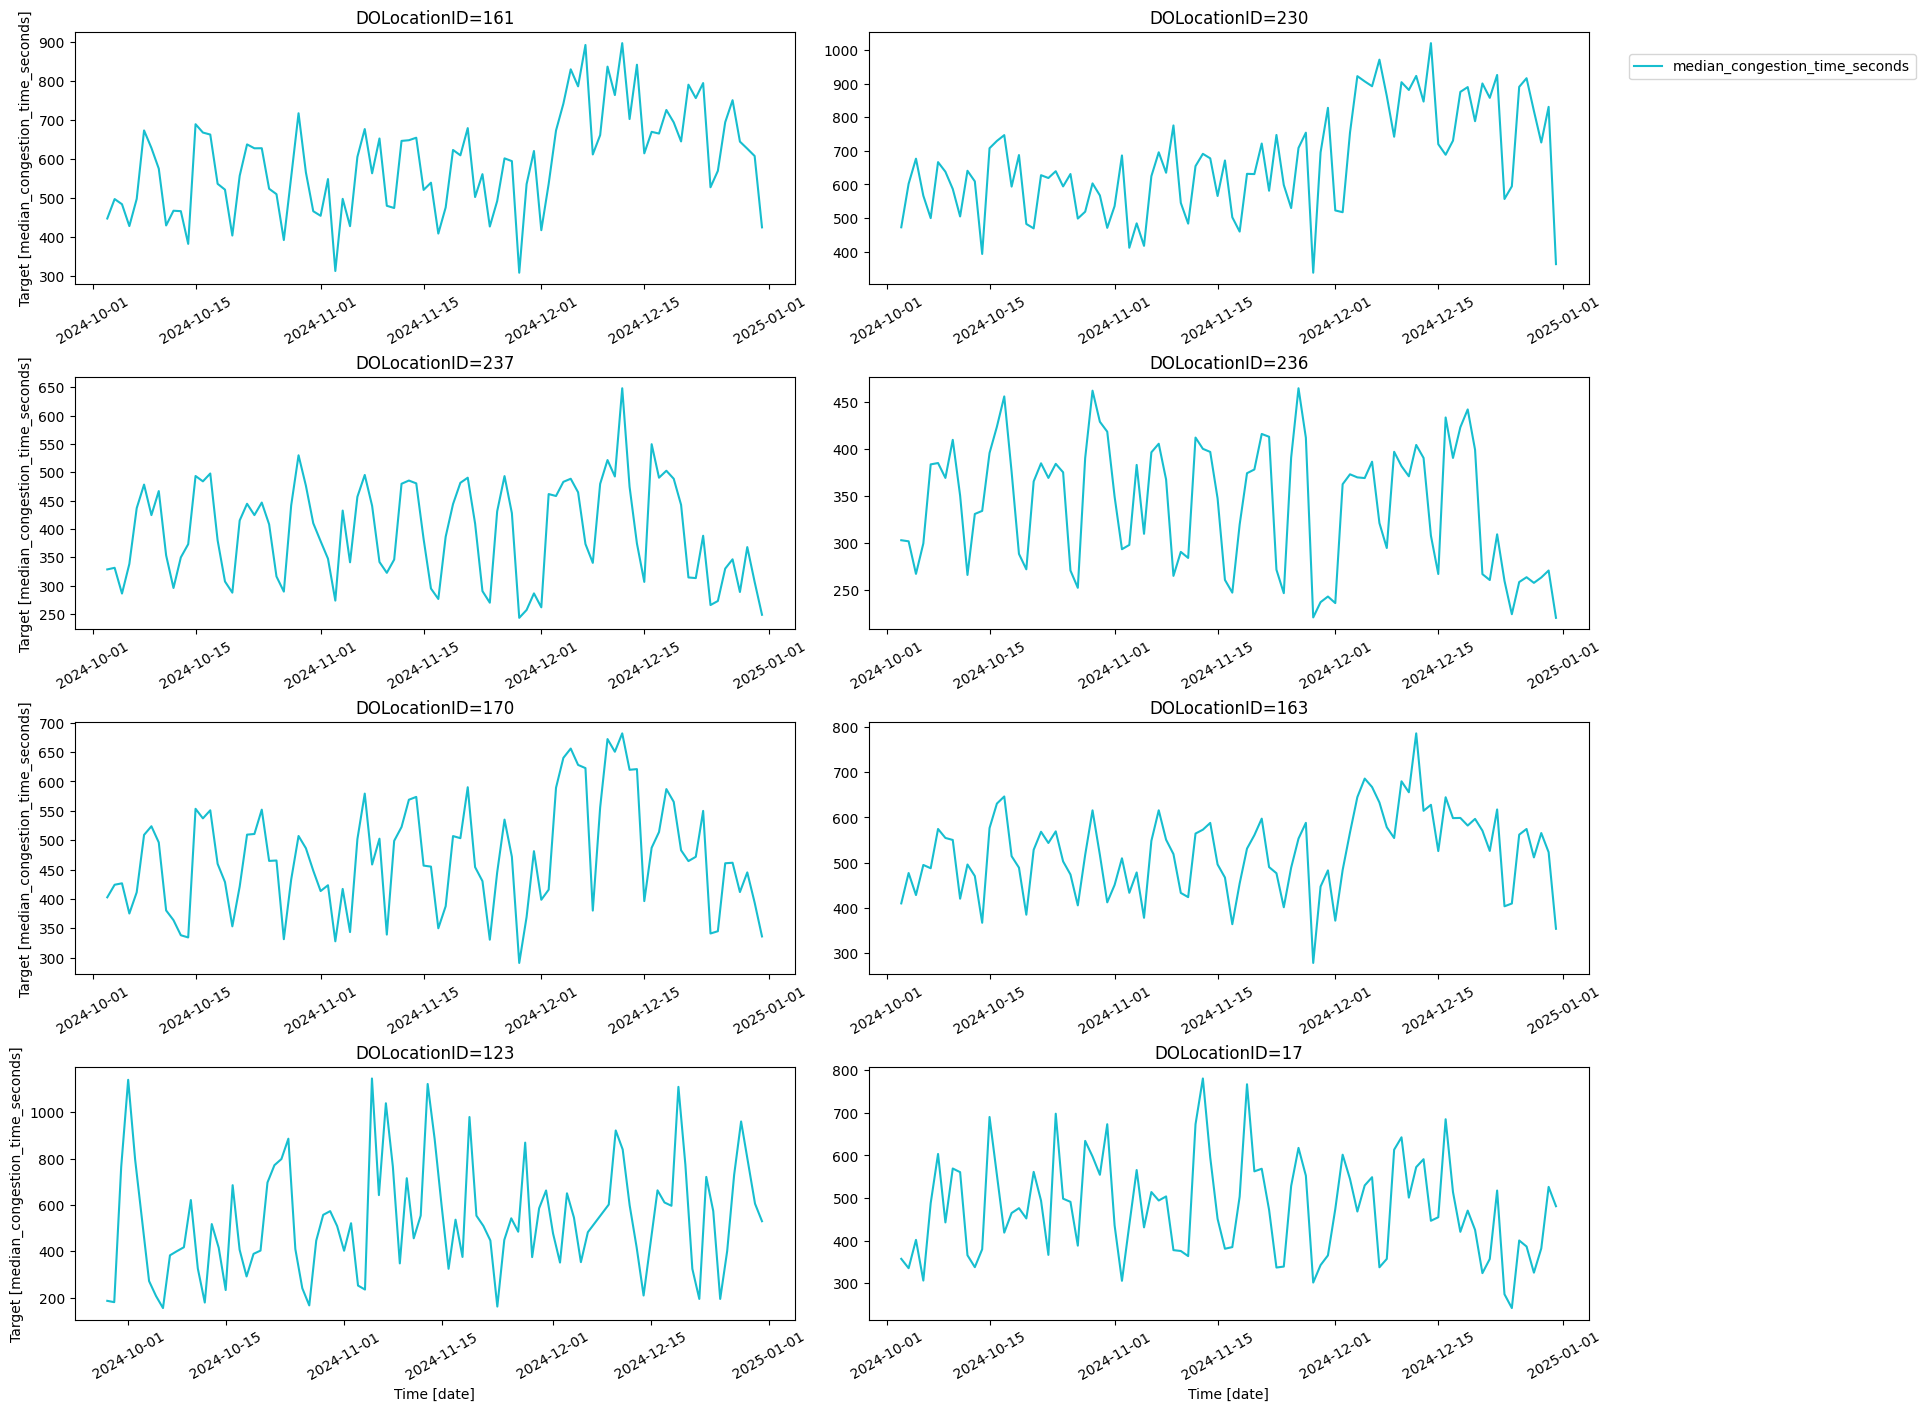

In [ ]:
dategroup_traindf_pd["date"] = pd.to_datetime(dategroup_traindf_pd["date"])
plot_series(
            df=dategroup_traindf_pd,
            ids =unique_ids, 
            time_col='date',
            target_col='median_congestion_time_seconds',
            id_col="DOLocationID",
            max_insample_length=90)

# max_insample_length = 30
# This is about 1 month of data for the LocationIDs in the unique_ids list 
# max_insample_length = 90
# This would be about 3 months of data for the LocationIDs in the unique_ids list


**Initially used 2023 July to 2024 December as the Training data and 2025 January to 2025 June as Test Data**

**Training Linear Regression Model without any lag features to predict known 2025 Data(Baseline)**

In [ ]:
# training only on the LocationIDs in the unique_ids list because the data is too large to train on all the LocationIDs
# this list contains the LocationIDs with the highest proportion of congestion time in NYC taxi rides in 2023 and 2024 and 2 random ones
train_data_subset = dategroup_traindf_pd[dategroup_traindf_pd["DOLocationID"].isin(unique_ids)]
test_data_subset = dategroup_testdf_pd[dategroup_testdf_pd["DOLocationID"].isin(unique_ids)]
train_data_subset.loc[:, "date"] = pd.to_datetime(train_data_subset["date"])
test_data_subset.loc[:, "date"] = pd.to_datetime(test_data_subset["date"])
train_data_subset.shape, test_data_subset.shape

((4309, 12), (1447, 12))

In [ ]:
# Using test_train_split does a random split on the dates making it so there is day leakage into the validation data per LocationID which makes predictions 
# seem better than should be

train_data, validation_data = train_test_split(train_data_subset, test_size=0.23, random_state=23)
train_data = train_data.sort_values(["DOLocationID", "date"]).reset_index(drop=True)
validation_data = validation_data.sort_values(["DOLocationID", "date"]).reset_index(drop=True)

train_data_x = train_data.drop(columns=["median_congestion_time_seconds"])
train_data_y = train_data["median_congestion_time_seconds"]

validation_data_x = validation_data.drop(columns=["median_congestion_time_seconds"])
validation_data_y = validation_data["median_congestion_time_seconds"]

# Full subsets of data without splitting 
test_data_x = test_data_subset.drop(columns=["median_congestion_time_seconds"])
test_data_y = test_data_subset["median_congestion_time_seconds"]

train_data_full = train_data_subset.drop(columns=["median_congestion_time_seconds"])
train_data_full_y = train_data_subset["median_congestion_time_seconds"]

In [ ]:
# Baseline prediction = mean of training target
baseline_pred = np.full_like(validation_data_y, train_data_y.mean())

# Evaluate baseline
baseline_r2 = r2_score(validation_data_y, baseline_pred)
baseline_mse = root_mean_squared_error(validation_data_y, baseline_pred)

print("Baseline R^2:", baseline_r2)
print("Baseline RMSE:", baseline_mse)

Baseline R^2: -0.0005522547458369775
Baseline RMSE: 170.03887406353127


In [ ]:
# Identify categorical and numeric columns
cat_cols = ["date", "DOLocationID"] 
num_cols = [c for c in train_data.drop(columns=["median_congestion_time_seconds"]).columns if c not in cat_cols]

# Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ]
)

lr_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", LassoCV(cv=5, random_state=23))
])

lr_model.fit(train_data_x, train_data_y)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['trip_count',
                                                   'daily_congestion',
                                                   'average_travel_time_seconds',
                                                   'total_trip_distance',
                                                   'average_trip_distance',
                                                   'total_fare_amount',
                                                   'total_tip_amount',
                                                   'total_amount',
                                                   'avg_total_amount']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['date', 'DOLocationID'])])),
                ('regressor', LassoCV(cv=5, random_state=23))])

In [ ]:
y_pred = lr_model.predict(validation_data_x)
print("R^2:", r2_score(validation_data_y, y_pred))
print("RMSE:", root_mean_squared_error(validation_data_y, y_pred))

R^2: 0.7775075262678016
RMSE: 80.18368207575669


In [ ]:
lr_model.fit(train_data_full, train_data_full_y)

y_pred_full = lr_model.predict(test_data_x)
print("R^2:", r2_score(test_data_y, y_pred_full))
print("RMSE:", root_mean_squared_error(test_data_y, y_pred_full))

R^2: 0.8543264803269696
RMSE: 41.580819257645395


**Then using all the data available i want to make predictions on the 2025 July for the selected LocationID's**

In [ ]:
train_data_full = pd.concat([train_data_subset, test_data_subset], ignore_index=True)
train_data_full = train_data_full.sort_values(["DOLocationID", "date"]).reset_index(drop=True)
train_data_full["date"] = pd.to_datetime(train_data_full["date"])

In [ ]:
for lag in range (1, 4): # account for 3 days of lag for each day
    train_data_full[f"median_congestion_lag{lag}"] = train_data_full.groupby("DOLocationID")["median_congestion_time_seconds"].shift(lag)
    train_data_full[f"average_travel_lag{lag}"] = train_data_full.groupby("DOLocationID")["average_travel_time_seconds"].shift(lag)
    train_data_full[f"average_tripd_lag{lag}"] = train_data_full.groupby("DOLocationID")["average_trip_distance"].shift(lag)
    train_data_full[f"average_total_amount_lag{lag}"] = train_data_full.groupby("DOLocationID")["avg_total_amount"].shift(lag)

train_data_full["trip_count_roll7"] = train_data_full.groupby("DOLocationID")["trip_count"].transform(lambda x: x.shift(1).rolling(7, min_periods=1).mean())
train_data_full["daily_congestion_roll7"] = train_data_full.groupby("DOLocationID")["daily_congestion"].transform(lambda x: x.shift(1).rolling(7, min_periods=1).mean())
train_data_full["total_trip_distance_roll7"] = train_data_full.groupby("DOLocationID")["total_trip_distance"].transform(lambda x: x.shift(1).rolling(7, min_periods=1).mean())
train_data_full["total_fare_amount_roll7"] = train_data_full.groupby("DOLocationID")["total_fare_amount"].transform(lambda x: x.shift(1).rolling(7, min_periods=1).mean())
train_data_full["total_tip_amount_roll7"] = train_data_full.groupby("DOLocationID")["total_tip_amount"].transform(lambda x: x.shift(1).rolling(7, min_periods=1).mean())
train_data_full["total_amount_roll7"] = train_data_full.groupby("DOLocationID")["total_amount"].transform(lambda x: x.shift(1).rolling(7, min_periods=1).mean())

train_data_full = train_data_full.dropna().copy()

**Firstly i keep aside around 20% of my all my data until 2025 June and evaluvate 3 models on the prediction of the 20% kept aside**

In [ ]:
y_columns = ["trip_count", "median_congestion_time_seconds", "daily_congestion",\
        "average_travel_time_seconds", "total_trip_distance", "average_trip_distance",\
        "total_fare_amount", "total_tip_amount", "total_amount", "avg_total_amount"]

cutoff_date = pd.to_datetime("2025-02-01") # roughly about 80% of the data until this day
train_mask = train_data_full["date"] < cutoff_date
X_train = train_data_full[train_mask].drop(columns=y_columns)  # features only
y_train = train_data_full[train_mask][y_columns]               # targets only

X_val = train_data_full[~train_mask].drop(columns=y_columns)
y_val = train_data_full[~train_mask][y_columns]

**Model 1: SGDRegressor**

In [ ]:
# input: ["DOLocationID", "date", 'median_congestion_lag1', 'average_travel_lag1', 'average_tripd_lag1','average_total_amount_lag1', 'median_congestion_lag2',\
# 'average_travel_lag2', 'average_tripd_lag2','average_total_amount_lag2','median_congestion_lag3', 'average_travel_lag3', 'average_tripd_lag3',\
# 'average_total_amount_lag3',"trip_count_roll7", 'daily_congestion_roll7', 'total_trip_dist_roll7','total_fare_roll7', 'total_tip_roll7', "total_amount_roll7"]

# output: ["trip_count", "median_congestion_time_seconds", "daily_congestion", "average_travel_time_seconds", "total_trip_distance", "average_trip_distance",\
# "total_fare_amount", "total_tip_amount", "total_amount", "avg_total_amount"]

def train_loop1(X_train, y):

    train_data = X_train.copy()
    train_data["day_of_week"] = train_data["date"].dt.dayofweek
    train_data["month"] = train_data["date"].dt.month
    train_data = train_data.drop(columns=["date"]) # no use for it after feature engineering
    train_features = train_data.columns.tolist() 
    
    # Identify categorical and numeric columns
    cat_cols = ["DOLocationID", "day_of_week", "month"] 
    num_cols = [c for c in train_data.columns if c not in cat_cols + y.columns.tolist()]

    # Preprocessor
    preprocessor = ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), num_cols),
            ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
        ]
    ) 

    #base_model = RandomForestRegressor(n_estimators=5023, random_state=23)

    base_model = SGDRegressor(penalty="elasticnet", max_iter=10230, random_state=23, l1_ratio=0.75, alpha=0.1, tol=1e-4, early_stopping=True, validation_fraction=0.1)
    

    columns_out_model = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("regressor", MultiOutputRegressor(base_model, n_jobs=-1))
    ])

    columns_out_model.fit(train_data, y)

    # fit model
    return columns_out_model, train_features, train_data

In [ ]:
def test_loop1(X_test, columns_out_model, y_columns, train_features, train_data_full):
    np.random.seed(23)
    X_test["date"] = pd.to_datetime(X_test["date"])

    features_to_lag = ['median_congestion_lag1', 'average_travel_lag1', 'average_tripd_lag1','average_total_amount_lag1', 'median_congestion_lag2',\
        'average_travel_lag2', 'average_tripd_lag2','average_total_amount_lag2','median_congestion_lag3', 'average_travel_lag3', 'average_tripd_lag3',\
        'average_total_amount_lag3'
    ]

    rolling_features = [
    "trip_count",
    "daily_congestion",
    "total_trip_distance",
    "total_fare_amount",
    "total_tip_amount",
    "total_amount"
]

    predictions = []
    history_df = X_test.copy()

    for col in rolling_features:
        if col not in history_df.columns:
            history_df[col] = train_data_full.loc[
                train_data_full["DOLocationID"].isin(history_df["DOLocationID"]), col]

    locations = history_df['DOLocationID'].unique()

    for day in pd.date_range("2025-02-01", "2025-06-30"):
        new_rows = [] # each day a new empty list of rows
        for loc in locations:

            lag_data = {"DOLocationID" : loc}

            # ---- engineered date features ----
            lag_data["day_of_week"] = day.dayofweek
            lag_data["month"] = day.month

            history_loc = history_df[history_df['DOLocationID'] == loc] # traversing for a given LocationID

            for f in features_to_lag:
                lag_step = int(f[-1])  # grab the lag number from the name
                if f in history_loc.columns and len(history_loc) >= lag_step:
                    lag_data[f] = history_loc[f].iloc[-lag_step]
                else:
                    lag_data[f] = 0
            
            for f in rolling_features:
                if f in history_loc.columns and len(history_loc) > 0:
                    lag_data[f"{f}_roll7"] = history_loc[f].shift(1).rolling(7, min_periods=1).mean().iloc[-1]
                
                else:
                    lag_data[f"{f}_roll7"] = 0 # for the first day when the column is empty

            

            X_day = pd.DataFrame([lag_data])
            X_day = X_day.reindex(columns=train_features, fill_value=0)
            
            y_pred = columns_out_model.predict(X_day)  # output shape: (1, num_initial_cols)

            # appending the predicted value to the history_df
            new_row = {"DOLocationID" : loc, "date" : day}

            for idx, f in enumerate(y_columns):
                new_row[f] = y_pred[0, idx]

            for col, val in lag_data.items():
                if col not in new_row:
                    new_row[col] = val

            new_rows.append(new_row)
            predictions.append(new_row)

        history_df = pd.concat([history_df, pd.DataFrame(new_rows)], ignore_index=True)

        history_df = history_df.sort_values(["DOLocationID", "date"]).reset_index(drop=True)
        history_df = history_df.sort_values(["DOLocationID", "date"]).drop_duplicates(subset=["DOLocationID", "date"], keep="last")

        
    history_df = history_df.sort_values(["DOLocationID", "date"]).reset_index(drop=True)
    return history_df, predictions

In [ ]:
model1, train_features, train_data = train_loop1(X_train, y_train)

cutoff2 = pd.to_datetime("2025-01-25")  # start of last week of Jan
history_df = X_train[X_train["date"] >= cutoff2].copy()
validation_df, validation_preds = test_loop1(history_df, model1, y_columns, train_features, train_data_full)

In [ ]:
twenty_percent_df = validation_df[validation_df["date"] >= pd.to_datetime("2025-02-01")]

twenty_percent_actual_df = train_data_full[~train_mask]

In [ ]:
print("R^2:", r2_score(twenty_percent_actual_df["median_congestion_time_seconds"], twenty_percent_df["median_congestion_time_seconds"]))
print("RMSE:", root_mean_squared_error(twenty_percent_actual_df["median_congestion_time_seconds"], twenty_percent_df["median_congestion_time_seconds"]))

R^2: 0.3325831014741383
RMSE: 87.94002086122099


**Model 2: XGBRegressor**

In [ ]:
# input: ["DOLocationID", "date", 'median_congestion_lag1', 'average_travel_lag1', 'average_tripd_lag1','average_total_amount_lag1', 'median_congestion_lag2',\
# 'average_travel_lag2', 'average_tripd_lag2','average_total_amount_lag2','median_congestion_lag3', 'average_travel_lag3', 'average_tripd_lag3',\
# 'average_total_amount_lag3',"trip_count_roll7", 'daily_congestion_roll7', 'total_trip_dist_roll7','total_fare_roll7', 'total_tip_roll7', "total_amount_roll7"]

# output: ["trip_count", "median_congestion_time_seconds", "daily_congestion", "average_travel_time_seconds", "total_trip_distance", "average_trip_distance",\
# "total_fare_amount", "total_tip_amount", "total_amount", "avg_total_amount"]

def train_loop2(X_train, y):

    train_data = X_train.copy()
    train_data["day_of_week"] = train_data["date"].dt.dayofweek
    train_data["month"] = train_data["date"].dt.month
    train_data = train_data.drop(columns=["date"]) # no use for it after feature engineering
    train_features = train_data.columns.tolist() 
    
    # Identify categorical and numeric columns
    cat_cols = ["DOLocationID", "day_of_week", "month"] 
    num_cols = [c for c in train_data.columns if c not in cat_cols + y.columns.tolist()]

    # Preprocessor
    preprocessor = ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), num_cols),
            ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
        ]
    ) 

    #base_model = RandomForestRegressor(n_estimators=5023, random_state=23)

    base_model = XGBRegressor(n_estimators=1023, learning_rate=0.05, max_depth=10, random_state=23, n_jobs=-1, tree_method="hist", reg_alpha=0.8)
    

    columns_out_model = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("regressor", MultiOutputRegressor(base_model, n_jobs=-1))
    ])

    columns_out_model.fit(train_data, y)

    # fit model
    return columns_out_model, train_features, train_data

In [ ]:
model1, train_features, train_data = train_loop2(X_train, y_train)

cutoff2 = pd.to_datetime("2025-01-25")  # start of last week of Jan
history_df = X_train[X_train["date"] >= cutoff2].copy()
validation_df, validation_preds = test_loop1(history_df, model1, y_columns, train_features, train_data_full)

In [ ]:
twenty_percent_df = validation_df[validation_df["date"] >= pd.to_datetime("2025-02-01")]

twenty_percent_actual_df = train_data_full[~train_mask]

In [ ]:
print("R^2:", r2_score(twenty_percent_actual_df["median_congestion_time_seconds"], twenty_percent_df["median_congestion_time_seconds"]))
print("RMSE:", root_mean_squared_error(twenty_percent_actual_df["median_congestion_time_seconds"], twenty_percent_df["median_congestion_time_seconds"]))

R^2: 0.22339700651960093
RMSE: 94.86095557714462


**Model 3: MLPRegressor**

In [ ]:
# input: ["DOLocationID", "date", 'median_congestion_lag1', 'average_travel_lag1', 'average_tripd_lag1','average_total_amount_lag1', 'median_congestion_lag2',\
# 'average_travel_lag2', 'average_tripd_lag2','average_total_amount_lag2','median_congestion_lag3', 'average_travel_lag3', 'average_tripd_lag3',\
# 'average_total_amount_lag3',"trip_count_roll7", 'daily_congestion_roll7', 'total_trip_dist_roll7','total_fare_roll7', 'total_tip_roll7', "total_amount_roll7"]

# output: ["trip_count", "median_congestion_time_seconds", "daily_congestion", "average_travel_time_seconds", "total_trip_distance", "average_trip_distance",\
# "total_fare_amount", "total_tip_amount", "total_amount", "avg_total_amount"]

def train_loop3(X_train, y):

    train_data = X_train.copy()
    train_data["day_of_week"] = train_data["date"].dt.dayofweek
    train_data["month"] = train_data["date"].dt.month
    train_data = train_data.drop(columns=["date"]) # no use for it after feature engineering
    train_features = train_data.columns.tolist() 
    
    # Identify categorical and numeric columns
    cat_cols = ["DOLocationID", "day_of_week", "month"] 
    num_cols = [c for c in train_data.columns if c not in cat_cols + y.columns.tolist()]

    # Preprocessor
    preprocessor = ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), num_cols),
            ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
        ]
    ) 
    
    columns_out_model = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("regressor", MLPRegressor(solver="adam", random_state=23, early_stopping=True, learning_rate_init=0.001, max_iter=10000,\
        hidden_layer_sizes=(100, 100, 100), alpha=0.000155, activation="relu", beta_2=0.9999))
    ])

    y_scaler = StandardScaler()
    y_train_scaled = y_scaler.fit_transform(y)

    columns_out_model.fit(train_data, y_train_scaled)

    # fit model
    return columns_out_model, y_scaler, train_features, train_data

In [ ]:
def test_loop3(X_test, columns_out_model, y_columns, train_features, train_data_full, y_scaler):
    np.random.seed(23)
    X_test["date"] = pd.to_datetime(X_test["date"])

    features_to_lag = ['median_congestion_lag1', 'average_travel_lag1', 'average_tripd_lag1','average_total_amount_lag1', 'median_congestion_lag2',\
        'average_travel_lag2', 'average_tripd_lag2','average_total_amount_lag2','median_congestion_lag3', 'average_travel_lag3', 'average_tripd_lag3',\
        'average_total_amount_lag3'
    ]

    rolling_features = [
    "trip_count",
    "daily_congestion",
    "total_trip_distance",
    "total_fare_amount",
    "total_tip_amount",
    "total_amount"
]

    predictions = []
    history_df = X_test.copy()

    for col in rolling_features:
        if col not in history_df.columns:
            history_df[col] = train_data_full.loc[
                train_data_full["DOLocationID"].isin(history_df["DOLocationID"]), col]

    locations = history_df['DOLocationID'].unique()

    for day in pd.date_range("2025-02-01", "2025-06-30"):
        new_rows = [] # each day a new empty list of rows
        for loc in locations:

            lag_data = {"DOLocationID" : loc}

            # ---- engineered date features ----
            lag_data["day_of_week"] = day.dayofweek
            lag_data["month"] = day.month

            history_loc = history_df[history_df['DOLocationID'] == loc] # traversing for a given LocationID

            for f in features_to_lag:
                lag_step = int(f[-1])  # grab the lag number from the name
                if f in history_loc.columns and len(history_loc) >= lag_step:
                    lag_data[f] = history_loc[f].iloc[-lag_step]
                else:
                    lag_data[f] = 0
            
            for f in rolling_features:
                if f in history_loc.columns and len(history_loc) > 0:
                    lag_data[f"{f}_roll7"] = history_loc[f].shift(1).rolling(7, min_periods=1).mean().iloc[-1]
                
                else:
                    lag_data[f"{f}_roll7"] = 0 # for the first day when the column is empty

            

            X_day = pd.DataFrame([lag_data])
            X_day = X_day.reindex(columns=train_features, fill_value=0)
            
            y_pred_scaled = columns_out_model.predict(X_day)  # output shape: (1, num_initial_cols)

            y_pred_original = y_scaler.inverse_transform(y_pred_scaled)

            # appending the predicted value to the history_df
            new_row = {"DOLocationID" : loc, "date" : day}

            for idx, f in enumerate(y_columns):
                new_row[f] = y_pred_original[0, idx]

            for col, val in lag_data.items():
                if col not in new_row:
                    new_row[col] = val

            new_rows.append(new_row)
            predictions.append(new_row)

        history_df = pd.concat([history_df, pd.DataFrame(new_rows)], ignore_index=True)

        history_df = history_df.sort_values(["DOLocationID", "date"]).reset_index(drop=True)
        history_df = history_df.sort_values(["DOLocationID", "date"]).drop_duplicates(subset=["DOLocationID", "date"], keep="last")

        
    history_df = history_df.sort_values(["DOLocationID", "date"]).reset_index(drop=True)
    return history_df, predictions

In [ ]:
model1, y_scaler, train_features, train_data = train_loop3(X_train, y_train)

cutoff2 = pd.to_datetime("2025-01-25")  # start of last week of Jan
history_df = X_train[X_train["date"] >= cutoff2].copy()
validation_df, validation_preds = test_loop3(history_df, model1, y_columns, train_features, train_data_full, y_scaler)

In [ ]:
twenty_percent_df = validation_df[validation_df["date"] >= pd.to_datetime("2025-02-01")]

twenty_percent_actual_df = train_data_full[~train_mask]

In [ ]:
print("R^2:", r2_score(twenty_percent_actual_df["median_congestion_time_seconds"], twenty_percent_df["median_congestion_time_seconds"]))
print("RMSE:", root_mean_squared_error(twenty_percent_actual_df["median_congestion_time_seconds"], twenty_percent_df["median_congestion_time_seconds"]))

R^2: 0.49454931047997863
RMSE: 76.52923317859435


**Visualizing predictions against actual data using best performing Model 3 for each LocationID's in the subset**

/var/folders/qf/25308l_17hv3chqx70wpnbqm0000gn/T/ipykernel_63826/3963980167.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  twenty_percent_df["date"] = pd.to_datetime(twenty_percent_df["date"])


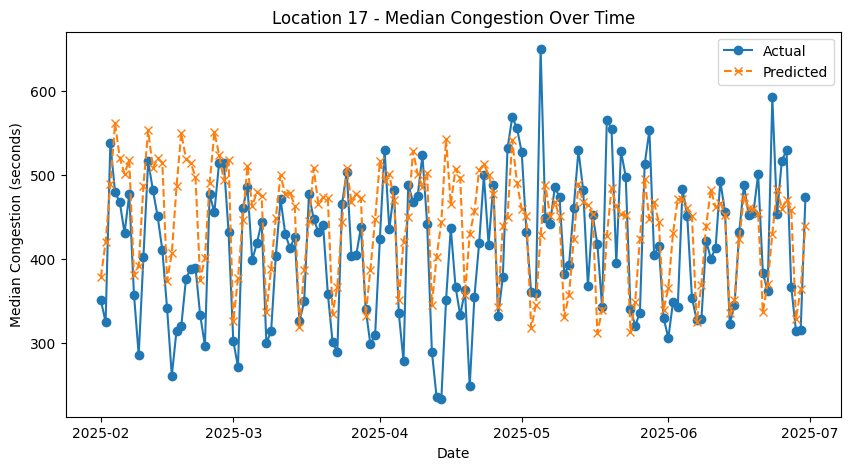

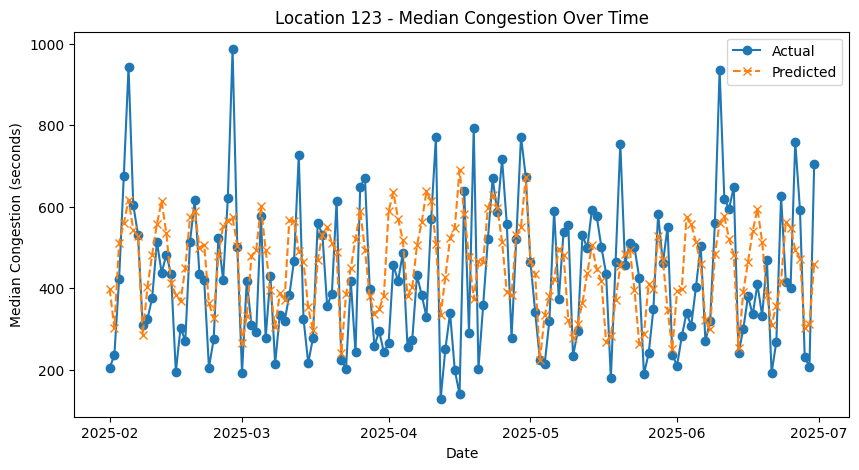

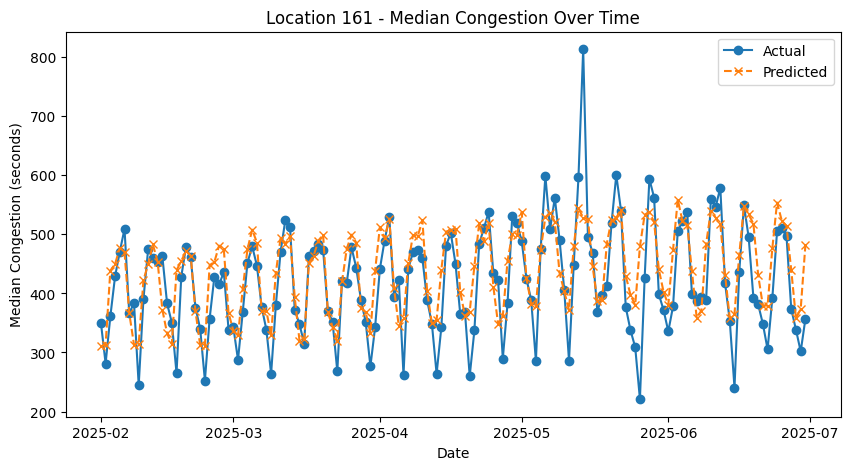

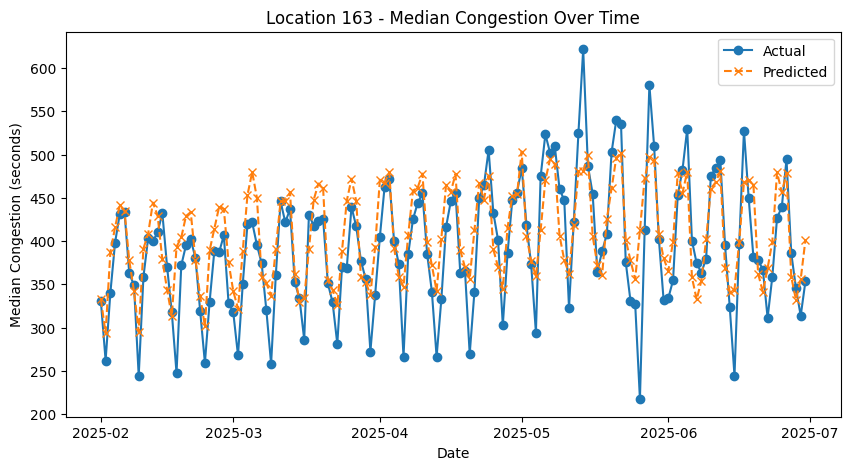

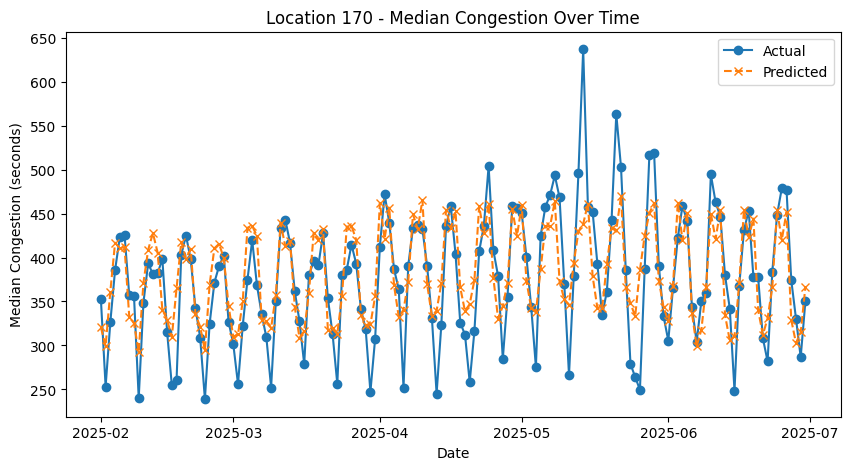

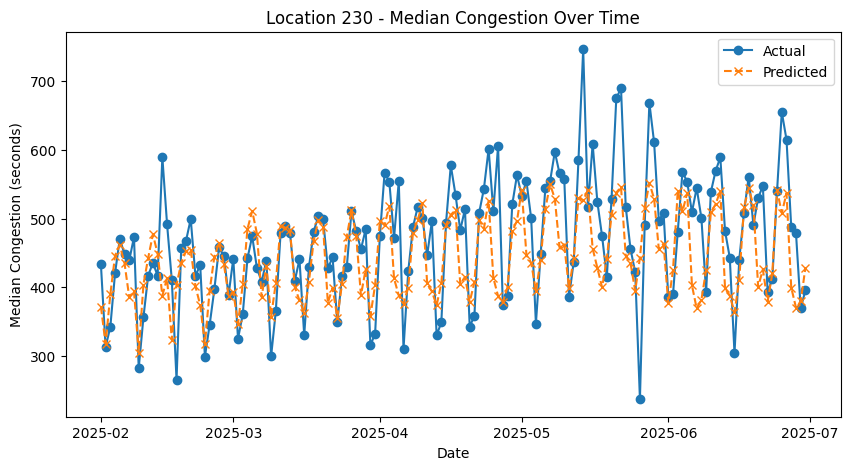

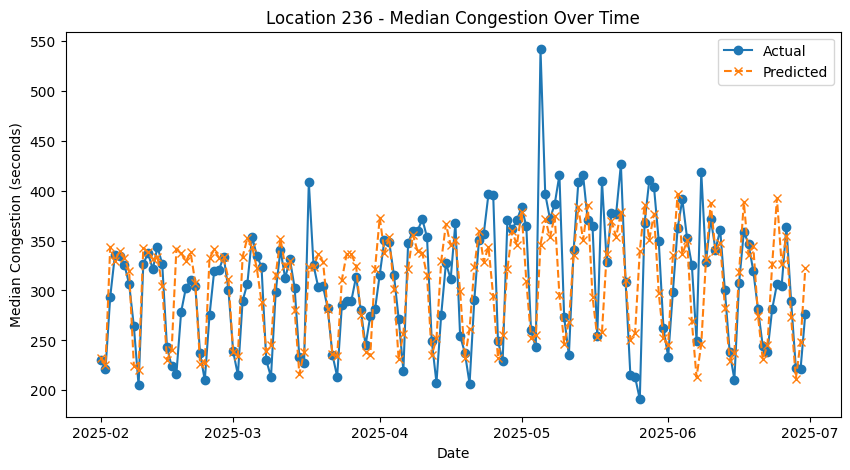

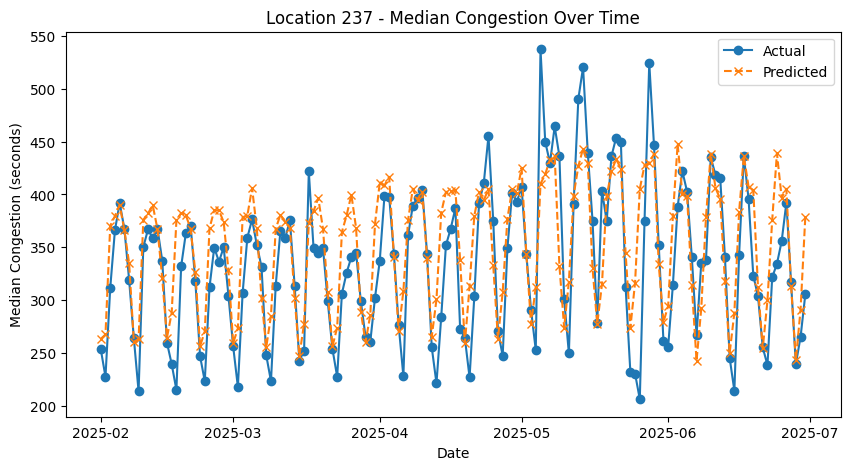

In [ ]:
twenty_percent_df["date"] = pd.to_datetime(twenty_percent_df["date"])

# Loop through each location
for loc in twenty_percent_actual_df["DOLocationID"].unique():
    actual_group = twenty_percent_actual_df[twenty_percent_actual_df["DOLocationID"] == loc]
    predicted_group = twenty_percent_df[twenty_percent_df["DOLocationID"] == loc]
    
    plt.figure(figsize=(10, 5))
    plt.plot(actual_group['date'], actual_group['median_congestion_time_seconds'], label="Actual", marker='o')
    plt.plot(predicted_group['date'], predicted_group['median_congestion_time_seconds'], label="Predicted", linestyle='--', marker='x')
    
    plt.xlabel("Date")
    plt.ylabel("Median Congestion (seconds)")
    plt.title(f"Location {loc} - Median Congestion Over Time")
    plt.legend()
    plt.show()

**Finally Predicting July 2025 congestion using best performing Model 3 for each LocationID's in the subset**

In [ ]:
# input: ["DOLocationID", "date", 'median_congestion_lag1', 'average_travel_lag1', 'average_tripd_lag1','average_total_amount_lag1', 'median_congestion_lag2',\
# 'average_travel_lag2', 'average_tripd_lag2','average_total_amount_lag2','median_congestion_lag3', 'average_travel_lag3', 'average_tripd_lag3',\
# 'average_total_amount_lag3',"trip_count_roll7", 'daily_congestion_roll7', 'total_trip_dist_roll7','total_fare_roll7', 'total_tip_roll7', "total_amount_roll7"]

# output: ["trip_count", "median_congestion_time_seconds", "daily_congestion", "average_travel_time_seconds", "total_trip_distance", "average_trip_distance",\
# "total_fare_amount", "total_tip_amount", "total_amount", "avg_total_amount"]

def train_loop4(X_train, y):

    train_data = X_train.copy()
    train_data["day_of_week"] = train_data["date"].dt.dayofweek
    train_data["month"] = train_data["date"].dt.month
    train_data = train_data.drop(columns=["date"]) # no use for it after feature engineering
    train_features = train_data.columns.tolist() 
    
    # Identify categorical and numeric columns
    cat_cols = ["DOLocationID", "day_of_week", "month"] 
    num_cols = [c for c in train_data.columns if c not in cat_cols + y.columns.tolist()]

    # Preprocessor
    preprocessor = ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), num_cols),
            ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
        ]
    ) 
    
    columns_out_model = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("regressor", MLPRegressor(solver="adam", random_state=23, early_stopping=True, learning_rate_init=0.001, max_iter=10000,\
        hidden_layer_sizes=(100, 100, 100), alpha=0.000155, activation="relu", beta_2=0.9999))
    ])

    y_scaler = StandardScaler()
    y_train_scaled = y_scaler.fit_transform(y)

    columns_out_model.fit(train_data, y_train_scaled)

    # fit model
    return columns_out_model, y_scaler, train_features, train_data

In [ ]:
def test_loop4(X_test, columns_out_model, y_columns, train_features, train_data_full, y_scaler):
    np.random.seed(23)
    X_test["date"] = pd.to_datetime(X_test["date"])

    features_to_lag = ['median_congestion_lag1', 'average_travel_lag1', 'average_tripd_lag1','average_total_amount_lag1', 'median_congestion_lag2',\
        'average_travel_lag2', 'average_tripd_lag2','average_total_amount_lag2','median_congestion_lag3', 'average_travel_lag3', 'average_tripd_lag3',\
        'average_total_amount_lag3'
    ]


    rolling_features = [
    "trip_count",
    "daily_congestion",
    "total_trip_distance",
    "total_fare_amount",
    "total_tip_amount",
    "total_amount"
]

    predictions = []
    history_df = X_test.copy()

    for col in rolling_features:
        if col not in history_df.columns:
            history_df[col] = train_data_full.loc[
                train_data_full["DOLocationID"].isin(history_df["DOLocationID"]), col]

    locations = history_df['DOLocationID'].unique()

    for day in pd.date_range("2025-07-01", "2025-07-31"):
        new_rows = [] # each day a new empty list of rows
        for loc in locations:

            lag_data = {"DOLocationID" : loc}

            # ---- engineered date features ----
            lag_data["day_of_week"] = day.dayofweek
            lag_data["month"] = day.month

            history_loc = history_df[history_df['DOLocationID'] == loc] # traversing for a given LocationID

            for f in features_to_lag:
                lag_step = int(f[-1])  # grab the lag number from the name
                if f in history_loc.columns and len(history_loc) >= lag_step:
                    lag_data[f] = history_loc[f].iloc[-lag_step]
                else:
                    lag_data[f] = 0
            
            for f in rolling_features:
                if f in history_loc.columns and len(history_loc) > 0:
                    lag_data[f"{f}_roll7"] = history_loc[f].shift(1).rolling(7, min_periods=1).mean().iloc[-1]
                
                else:
                    lag_data[f"{f}_roll7"] = 0 # for the first day when the column is empty

            

            X_day = pd.DataFrame([lag_data])
            X_day = X_day.reindex(columns=train_features, fill_value=0)
            
            y_pred_scaled = columns_out_model.predict(X_day)  # output shape: (1, num_initial_cols)

            y_pred_original = y_scaler.inverse_transform(y_pred_scaled)

            # appending the predicted value to the history_df
            new_row = {"DOLocationID" : loc, "date" : day}

            for idx, f in enumerate(y_columns):
                new_row[f] = y_pred_original[0, idx]

            for col, val in lag_data.items():
                if col not in new_row:
                    new_row[col] = val

            new_rows.append(new_row)
            predictions.append(new_row)

        history_df = pd.concat([history_df, pd.DataFrame(new_rows)], ignore_index=True)

        history_df = history_df.sort_values(["DOLocationID", "date"]).reset_index(drop=True)
        history_df = history_df.sort_values(["DOLocationID", "date"]).drop_duplicates(subset=["DOLocationID", "date"], keep="last")

        
    history_df = history_df.sort_values(["DOLocationID", "date"]).reset_index(drop=True)
    return history_df, predictions

In [ ]:
y_columns = ["trip_count", "median_congestion_time_seconds", "daily_congestion",\
        "average_travel_time_seconds", "total_trip_distance", "average_trip_distance",\
        "total_fare_amount", "total_tip_amount", "total_amount", "avg_total_amount"]

X_train_final = train_data_full.drop(columns=y_columns)  # features only
y_train_final = train_data_full[y_columns]               # targets only

In [ ]:
model1, y_scaler, train_features, train_data = train_loop4(X_train_final, y_train_final)

full_july_df, full_july_preds = test_loop4(X_train_final, model1, y_columns, train_features, train_data_full, y_scaler)

In [ ]:
full_july_df["date"] = pd.to_datetime(full_july_df["date"])

july_df = full_july_df[full_july_df["date"] >= pd.to_datetime("2025-07-01")]

**Visualizing predictions for 2025 July using best performing Model 3 for each LocationID's in the subset**

/var/folders/qf/25308l_17hv3chqx70wpnbqm0000gn/T/ipykernel_63826/3356370354.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  july_df["date"] = pd.to_datetime(july_df["date"])


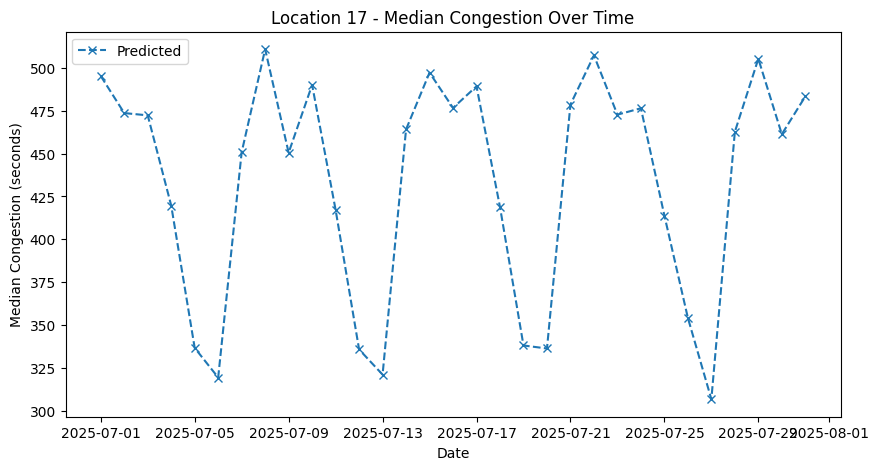

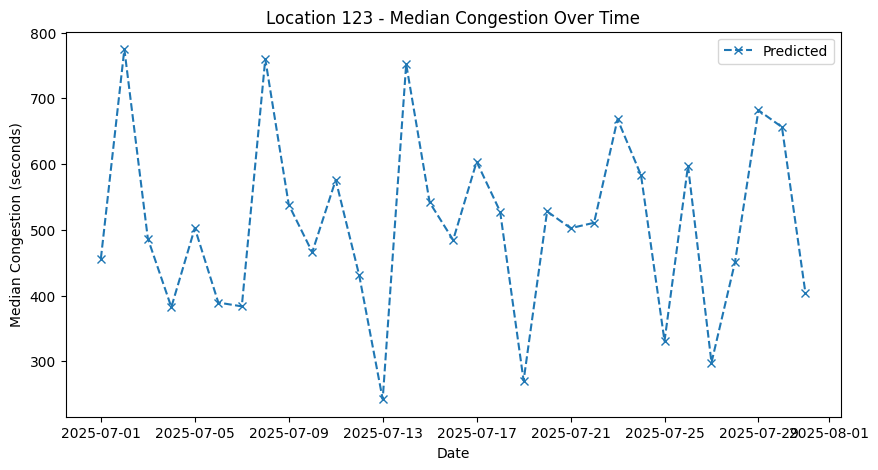

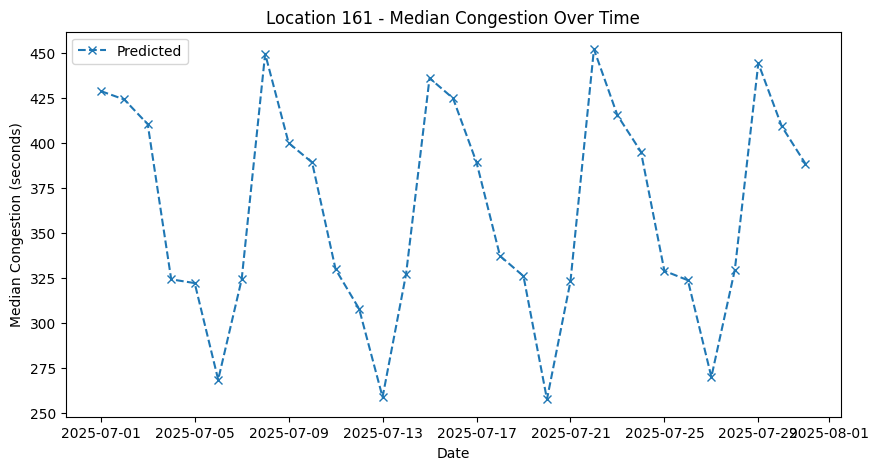

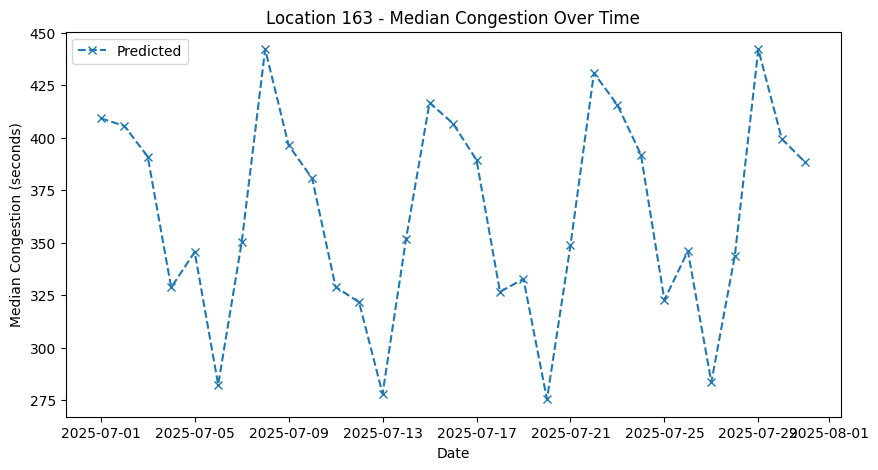

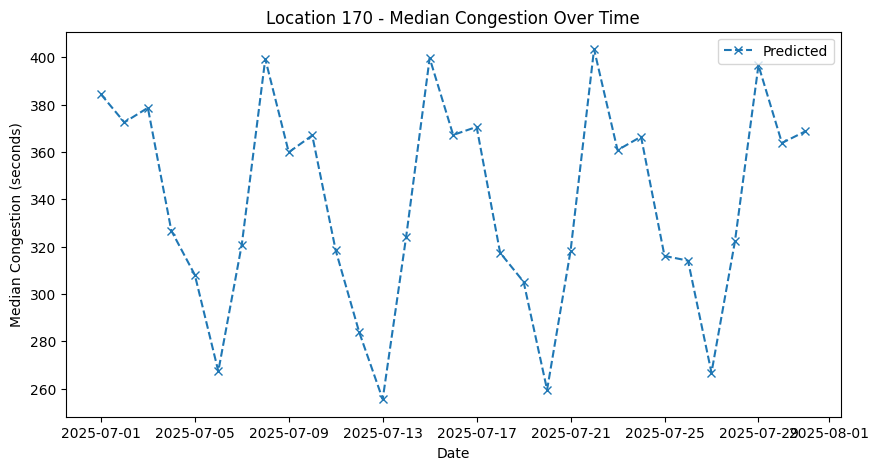

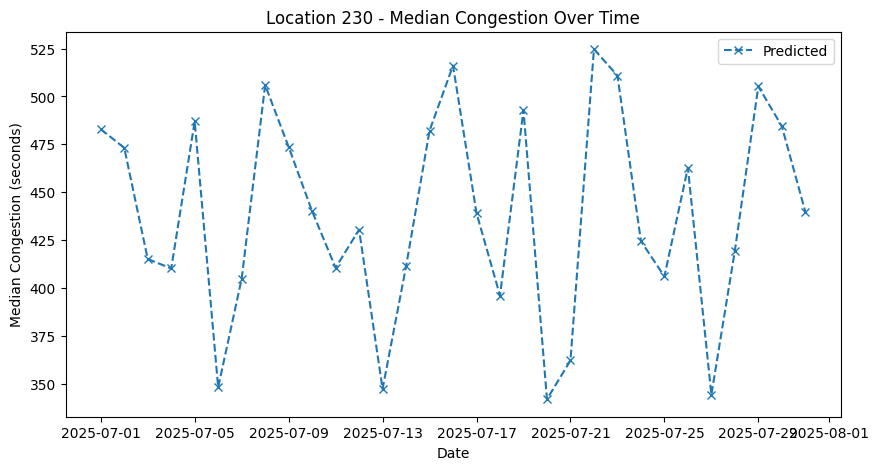

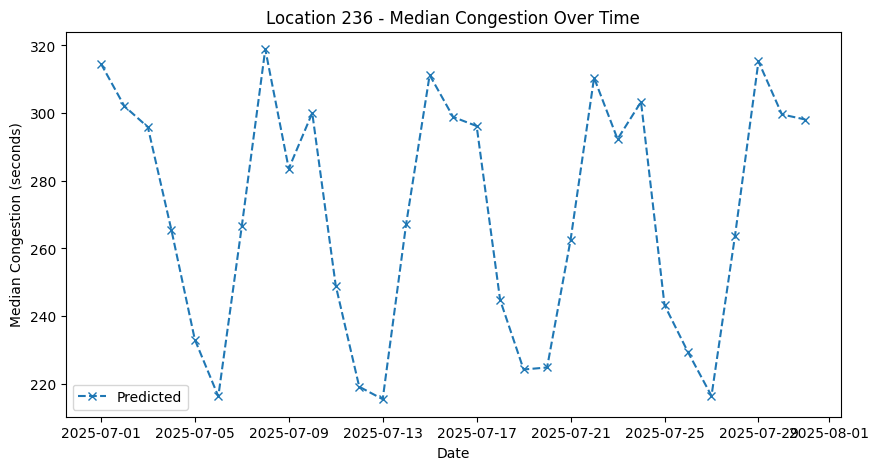

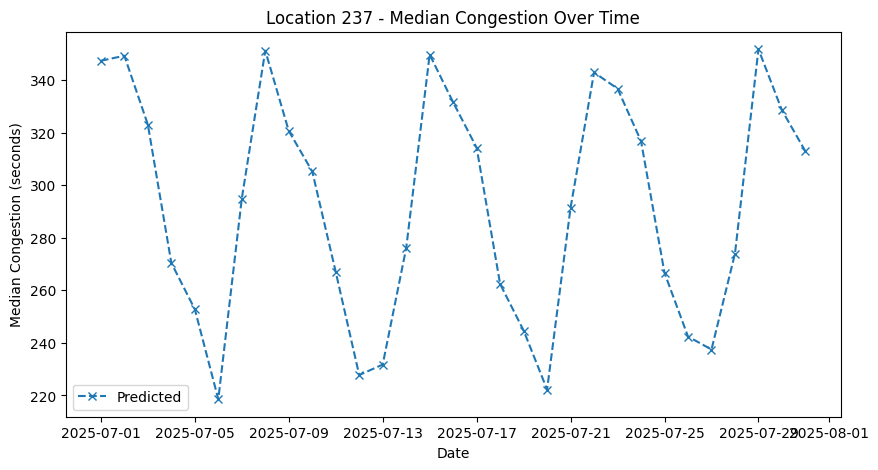

In [ ]:
july_df["date"] = pd.to_datetime(july_df["date"])

for loc in july_df["DOLocationID"].unique():
    predicted_group = july_df[july_df["DOLocationID"] == loc]
    
    plt.figure(figsize=(10, 5))
    plt.plot(predicted_group['date'], predicted_group['median_congestion_time_seconds'], label="Predicted", linestyle='--', marker='x')
    
    plt.xlabel("Date")
    plt.ylabel("Median Congestion (seconds)")
    plt.title(f"Location {loc} - Median Congestion Over Time")
    plt.legend()
    plt.show()